In [10]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import numpy as np
from scipy import stats

## Fetch Data

In [ ]:
LAT, LON = 56.1629, 10.2039  # Aarhus
START, END = "2025-04-18", "2026-04-18"

# ── 1. Historical air quality (NO2, O3) ──────────────────────────────────────
print("Fetching air quality...")
aq = requests.get(
    "https://air-quality-api.open-meteo.com/v1/air-quality",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "nitrogen_dioxide,ozone,pm10,pm2_5",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

aq_df = pd.DataFrame({
    "Recorded": pd.to_datetime(aq["hourly"]["time"]),
    "NO2":      aq["hourly"]["nitrogen_dioxide"],
    "O3":       aq["hourly"]["ozone"],
    "PM10":     aq["hourly"]["pm10"],
    "PM2.5":    aq["hourly"]["pm2_5"],
})

# ── 2. Historical weather (wind, rain, temp, radiation) ──────────────────────
print("Fetching weather...")
wx = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "wind_speed_10m,wind_direction_10m,temperature_2m,shortwave_radiation,precipitation,relative_humidity_2m",
        "wind_speed_unit": "ms",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

wx_df = pd.DataFrame({
    "Recorded":           pd.to_datetime(wx["hourly"]["time"]),
    "wind_speed":         wx["hourly"]["wind_speed_10m"],
    "wind_direction":     wx["hourly"]["wind_direction_10m"],
    "temperature":        wx["hourly"]["temperature_2m"],
    "solar_radiation":    wx["hourly"]["shortwave_radiation"],
    "precipitation":      wx["hourly"]["precipitation"],
    "humidity":           wx["hourly"]["relative_humidity_2m"],

})

# ── 3. Merge and save ─────────────────────────────────────────────────────────
print("Merging...")
df = aq_df.merge(wx_df, on="Recorded", how="inner")
df = df.sort_values("Recorded").reset_index(drop=True)

print(f"\nFinal shape: {df.shape}")
print(df.head())
print(f"\nDate range: {df.Recorded.min()} → {df.Recorded.max()}")
print(f"Missing values:\n{df.isnull().sum()}")

Fetching air quality...
Fetching weather...
Merging...

Final shape: (8784, 11)
             Recorded  NO2    O3  PM10  PM2.5  wind_speed  wind_direction  \
0 2025-04-18 00:00:00  3.4  90.0   3.8    2.9        4.52             327   
1 2025-04-18 01:00:00  3.1  91.0   3.2    2.6        4.51             320   
2 2025-04-18 02:00:00  2.5  95.0   3.0    2.1        4.40             326   
3 2025-04-18 03:00:00  2.7  92.0   3.1    2.0        4.44             329   
4 2025-04-18 04:00:00  2.6  87.0   3.4    2.6        4.70             327   

   temperature  solar_radiation  precipitation  humidity  
0          8.3              0.0            0.0        86  
1          7.9              0.0            0.0        87  
2          7.8              0.0            0.0        86  
3          7.8              0.0            0.0        91  
4          7.8              0.0            0.0        89  

Date range: 2025-04-18 00:00:00 → 2026-04-18 23:00:00
Missing values:
Recorded           0
NO2        

In [2]:
df.head()

,Recorded,NO2,O3,PM10,PM2.5,wind_speed,wind_direction,temperature,solar_radiation,precipitation,humidity
0,2025-04-18 00:00:00,3.4,90.0,3.8,2.9,4.52,327,8.3,0.0,0.0,86
1,2025-04-18 01:00:00,3.1,91.0,3.2,2.6,4.51,320,7.9,0.0,0.0,87
2,2025-04-18 02:00:00,2.5,95.0,3.0,2.1,4.40,326,7.8,0.0,0.0,86
3,2025-04-18 03:00:00,2.7,92.0,3.1,2.0,4.44,329,7.8,0.0,0.0,91
4,2025-04-18 04:00:00,2.6,87.0,3.4,2.6,4.70,327,7.8,0.0,0.0,89


In [3]:
df.describe()

,Recorded,NO2,O3,PM10,PM2.5,wind_speed,wind_direction,temperature,solar_radiation,precipitation,humidity
count,8784,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,2025-10-17 23:30:00,5.890323,62.808743,9.457548,6.268682,4.536544,200.297245,9.284927,127.780965,0.084028,80.302140
min,2025-04-18 00:00:00,0.600000,4.000000,1.700000,1.000000,0.050000,1.000000,-9.900000,0.000000,0.000000,22.000000
25%,2025-07-18 11:45:00,2.900000,53.000000,5.900000,3.300000,3.060000,138.000000,4.400000,0.000000,0.000000,72.000000
50%,2025-10-17 23:30:00,4.700000,63.500000,8.300000,4.800000,4.380000,209.000000,9.400000,5.000000,0.000000,83.000000
75%,2026-01-17 11:15:00,7.600000,74.000000,11.600000,7.700000,5.850000,271.000000,14.500000,187.000000,0.000000,91.000000
max,2026-04-18 23:00:00,31.300000,130.000000,44.900000,39.300000,14.450000,360.000000,27.200000,854.000000,11.200000,100.000000
std,NaN,4.194668,16.688392,5.038248,4.511350,2.035604,83.992296,6.836569,200.151520,0.397420,13.985004


# Plot last week of data:

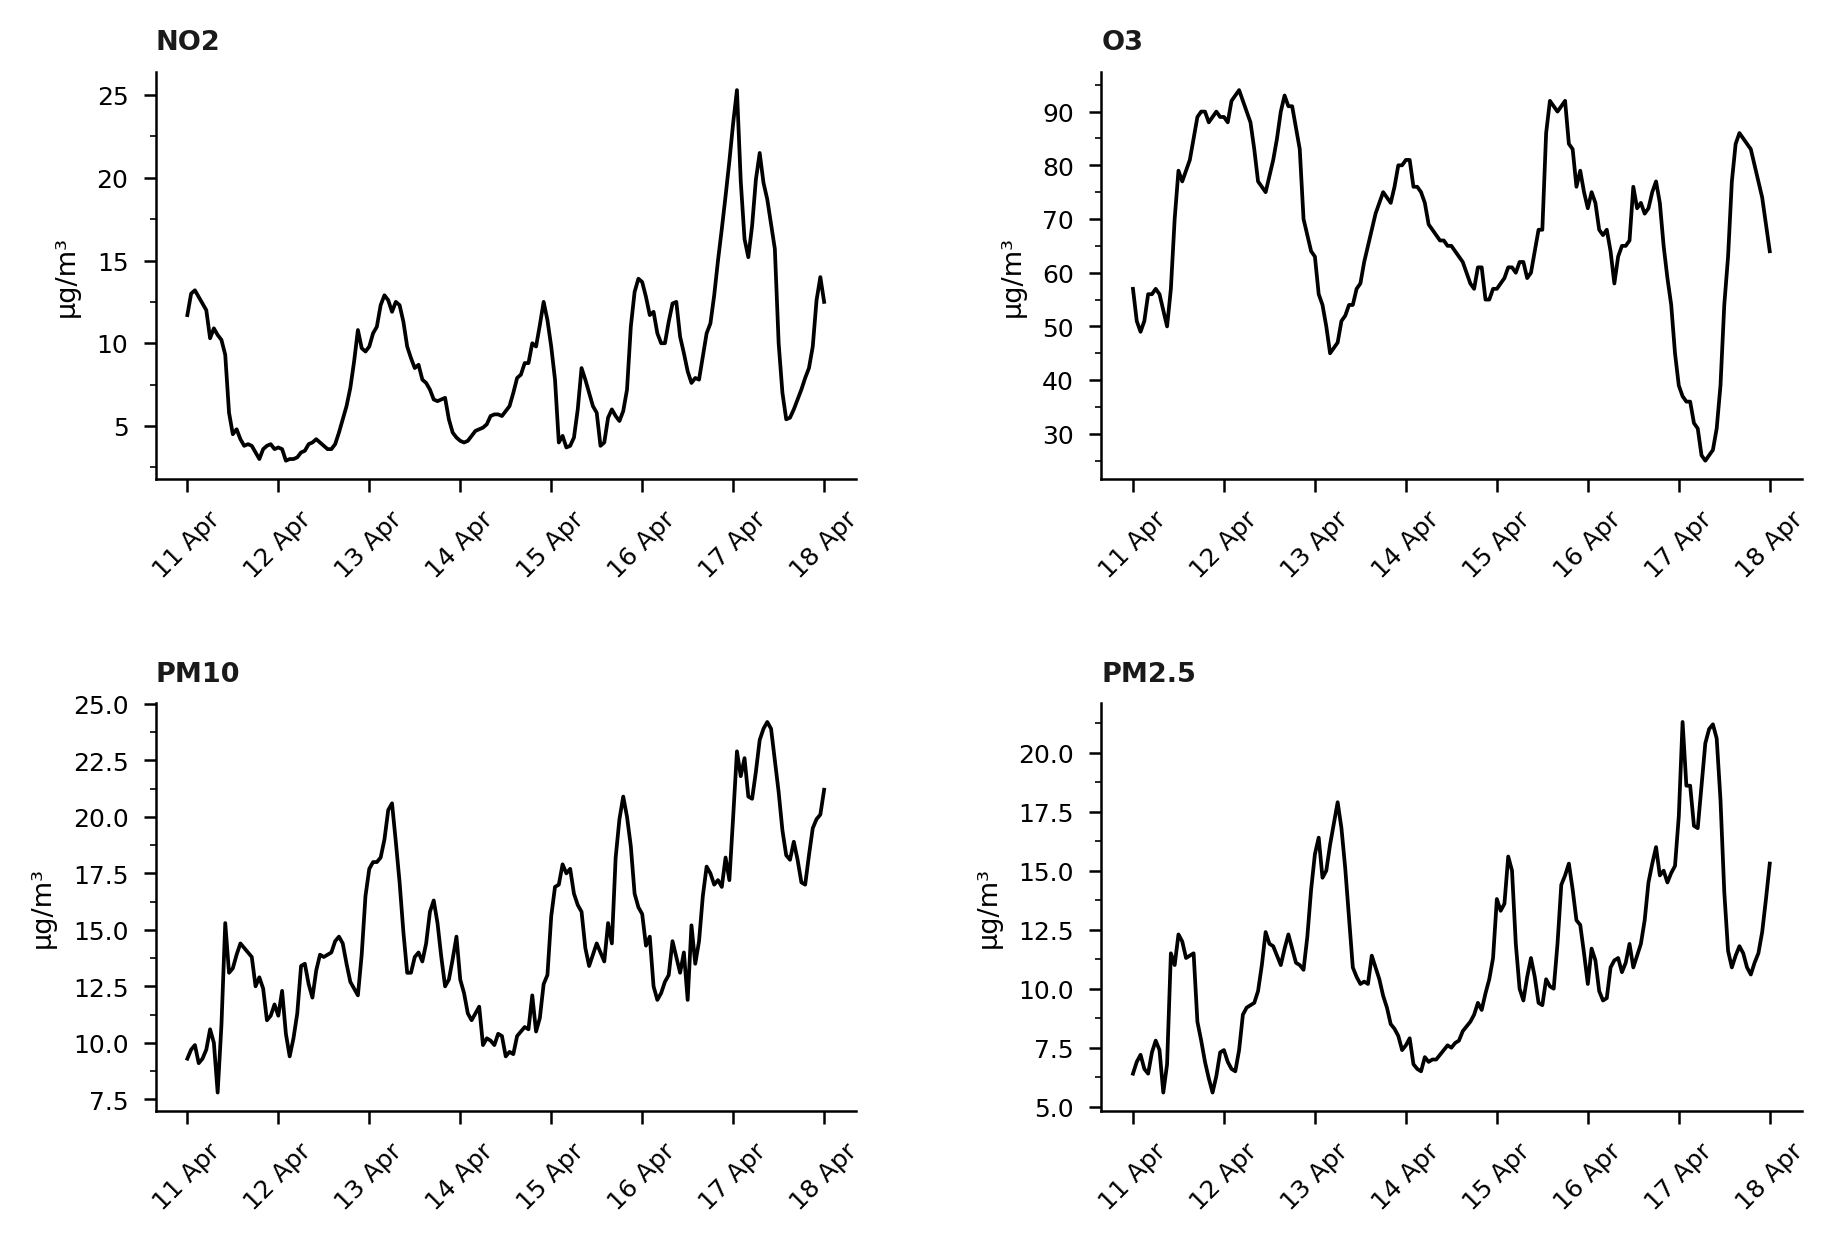

In [9]:
df_filtered = df[
    (df["Recorded"] >= "2026-04-11 00:00:00") &
    (df["Recorded"] <= "2026-04-18 00:00:00")
]
# ── Matplotlib RC for Nature-style ───────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["DejaVu Sans", "Helvetica", "Arial"],
    "font.size":          7,
    "axes.labelsize":     7,
    "axes.titlesize":     7,
    "xtick.labelsize":    6,
    "ytick.labelsize":    6,
    "axes.linewidth":     0.6,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.minor.width":  0.4,
    "ytick.minor.width":  0.4,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "xtick.minor.size":   1.5,
    "ytick.minor.size":   1.5,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          False,
    "legend.fontsize":    6,
    "legend.frameon":     False,
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "lines.linewidth":    0.9,
    "lines.antialiased":  True,
})

cols = ["NO2", "O3", "PM10", "PM2.5"]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 2,
    figsize=(7.08, 4.5),
)
axes = axes.flatten()

date_fmt = mdates.DateFormatter("%-d %b")   # "11 Apr" — Linux/Mac
# On Windows use: mdates.DateFormatter("%#d %b")

for ax, col in zip(axes, cols):
    t = df_filtered["Recorded"]
    y = df_filtered[col]

    ax.plot(t, y, color="black", linewidth=0.9)

    # ── Col name at top of y-axis ─────────────────────────────────────────
    ax.text(
        0, 1.04,
        col,
        transform=ax.transAxes,
        fontsize=6.5,
        va="bottom",
        ha="left",
        color="#1a1a1a",
        fontweight="bold",
    )

    # ── µg/m³ as the y-axis label ─────────────────────────────────────────
    ax.set_ylabel("µg/m³", fontsize=6.5)

    # ── X-axis: every date, on every panel ───────────────────────────────
    ax.xaxis.set_major_formatter(date_fmt)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="x", which="both", labelbottom=True)

    # ── Y minor ticks ─────────────────────────────────────────────────────
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

plt.subplots_adjust(hspace=0.55, wspace=0.35)
plt.show()


# Daily seasonality Plots

In [13]:
df["Recorded"] = pd.to_datetime(df["Recorded"])

df = df[
    (df["Recorded"] >= "2022-01-01") &
    (df["Recorded"] <= "2026-04-18")
].copy()

# Extract time components
df["year"] = df["Recorded"].dt.year
df["month"] = df["Recorded"].dt.month
df["dayofyear"] = df["Recorded"].dt.dayofyear
df["hour"] = df["Recorded"].dt.hour
df["week"] = df["Recorded"].dt.isocalendar().week

In [16]:
def hourly_pattern_ci(df, value_col):
    """
    Single plot: hourly mean + 95% CI across all years.
    """

    hourly = (
        df.groupby("hour")[value_col]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("hour")
    )

    hourly["sem"] = hourly["std"] / np.sqrt(hourly["count"])
    t_crit = stats.t.ppf(0.975, np.maximum(hourly["count"] - 1, 1))
    ci = t_crit * hourly["sem"]

    plt.figure(figsize=(12, 6))
    plt.plot(hourly["hour"], hourly["mean"], color="black", linewidth=2)
    plt.fill_between(
        hourly["hour"],
        hourly["mean"] - ci,
        hourly["mean"] + ci,
        color="black",
        alpha=0.15
    )

    plt.xticks(range(24))
    plt.xlabel("Hour of day")
    plt.ylabel(value_col)
    plt.title(f"Hourly pattern with 95% CI ({value_col})")
    plt.tight_layout()
    plt.show()

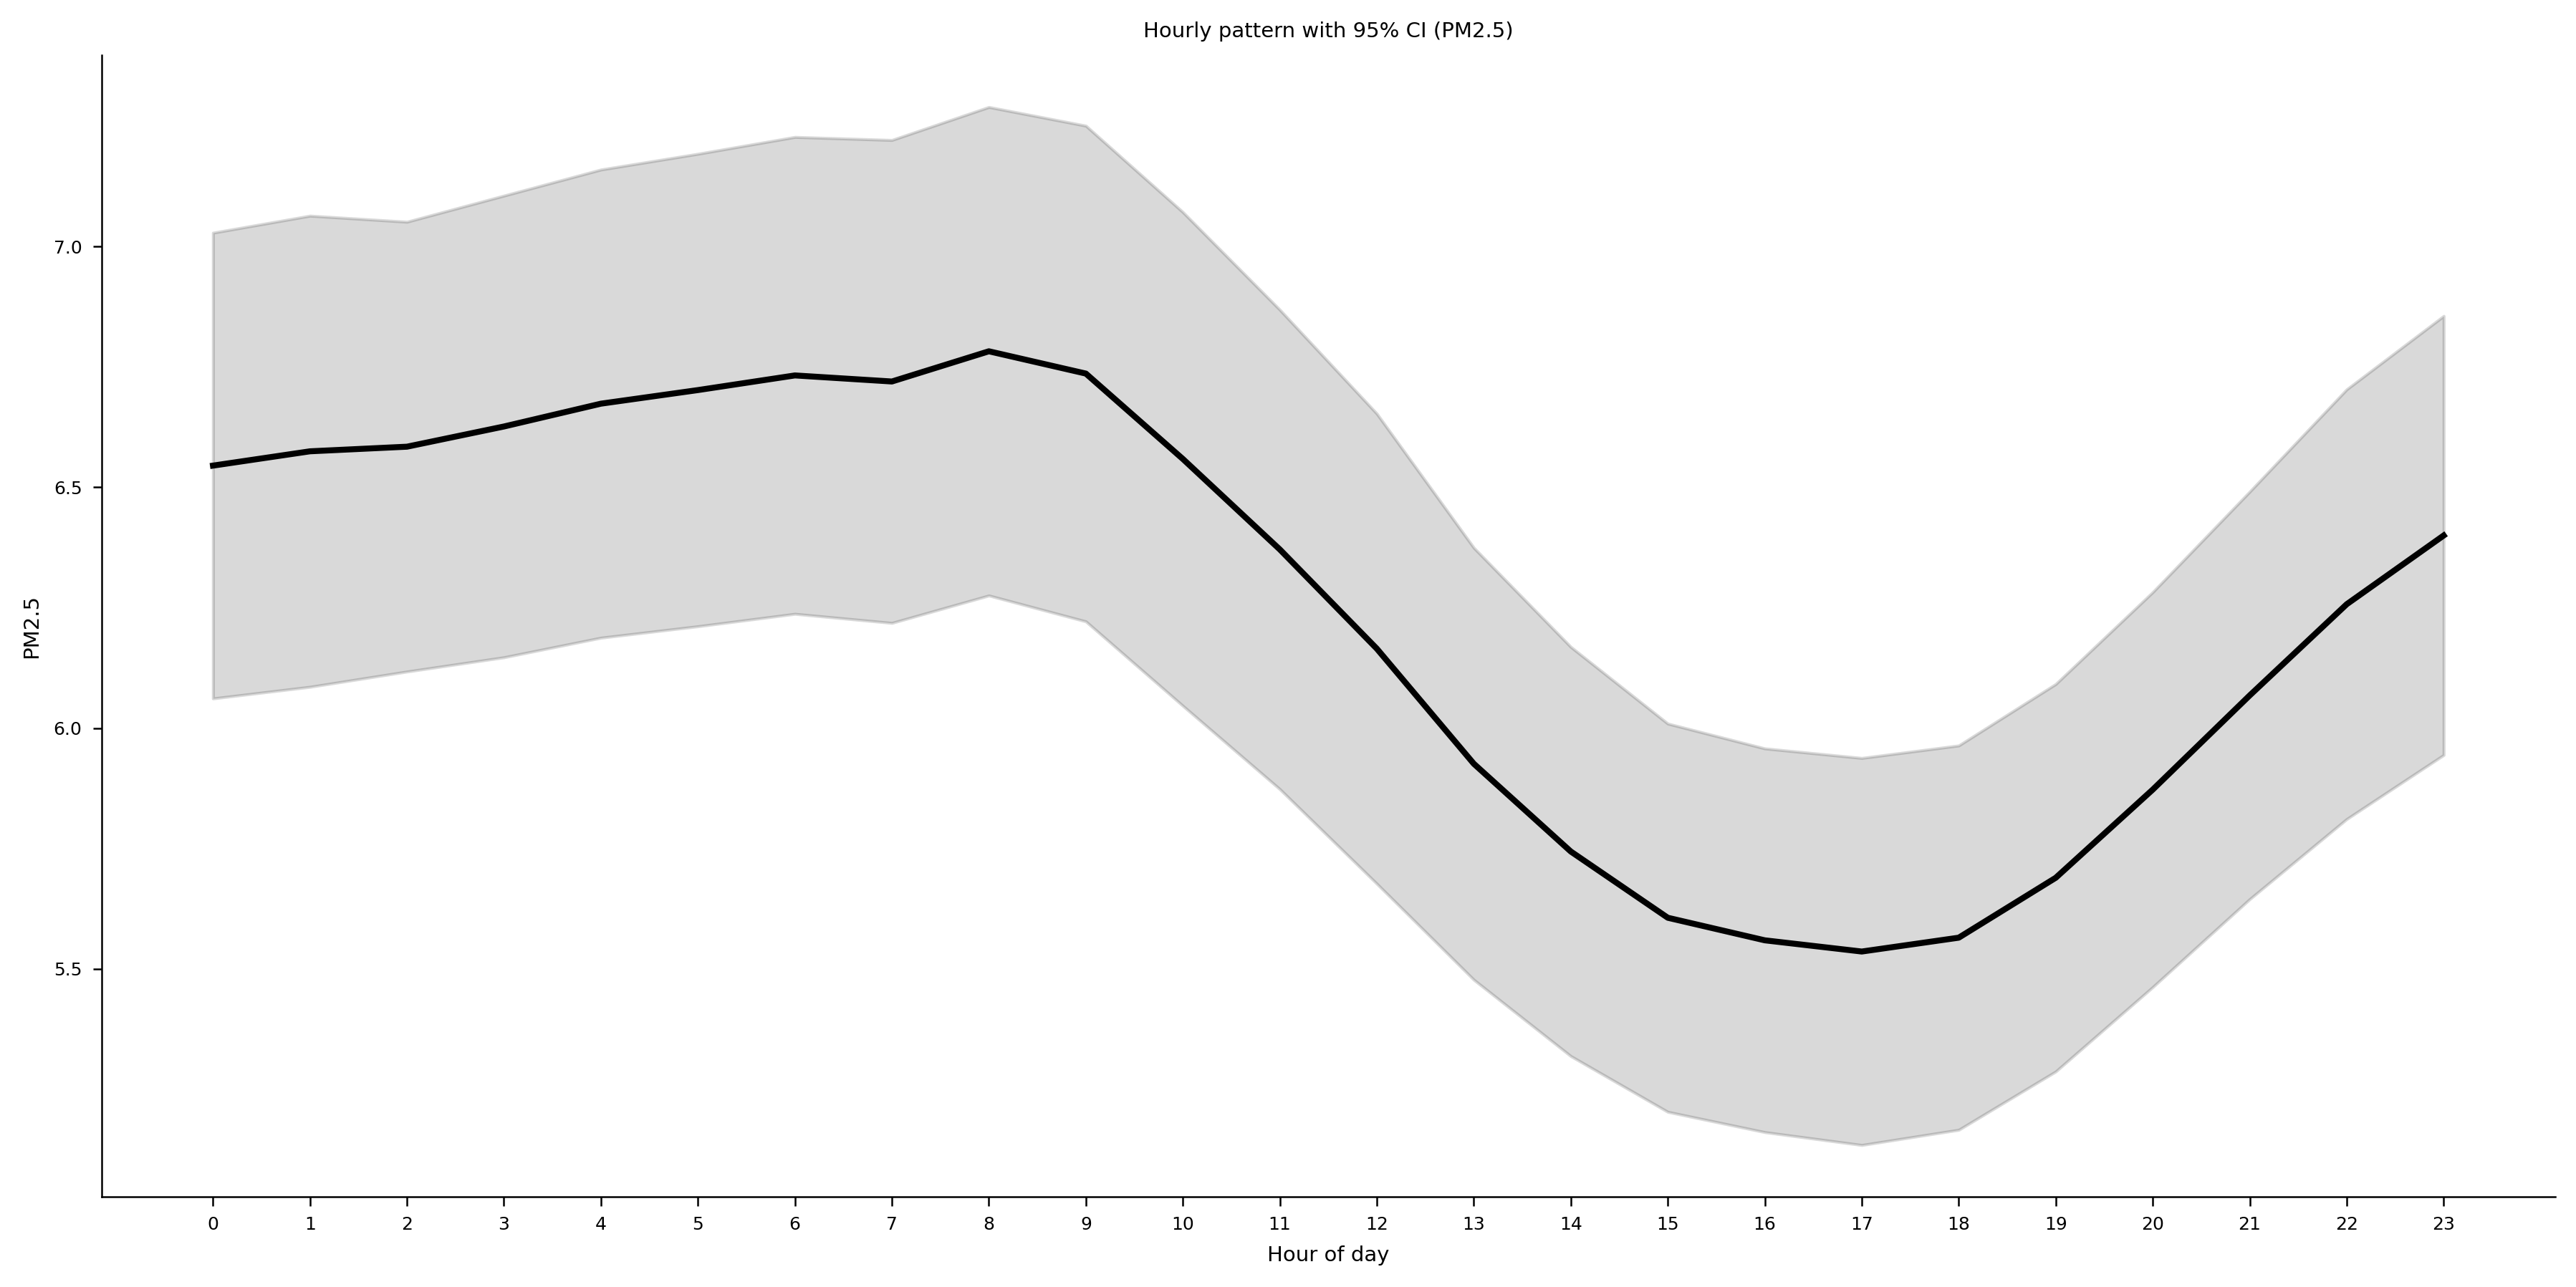

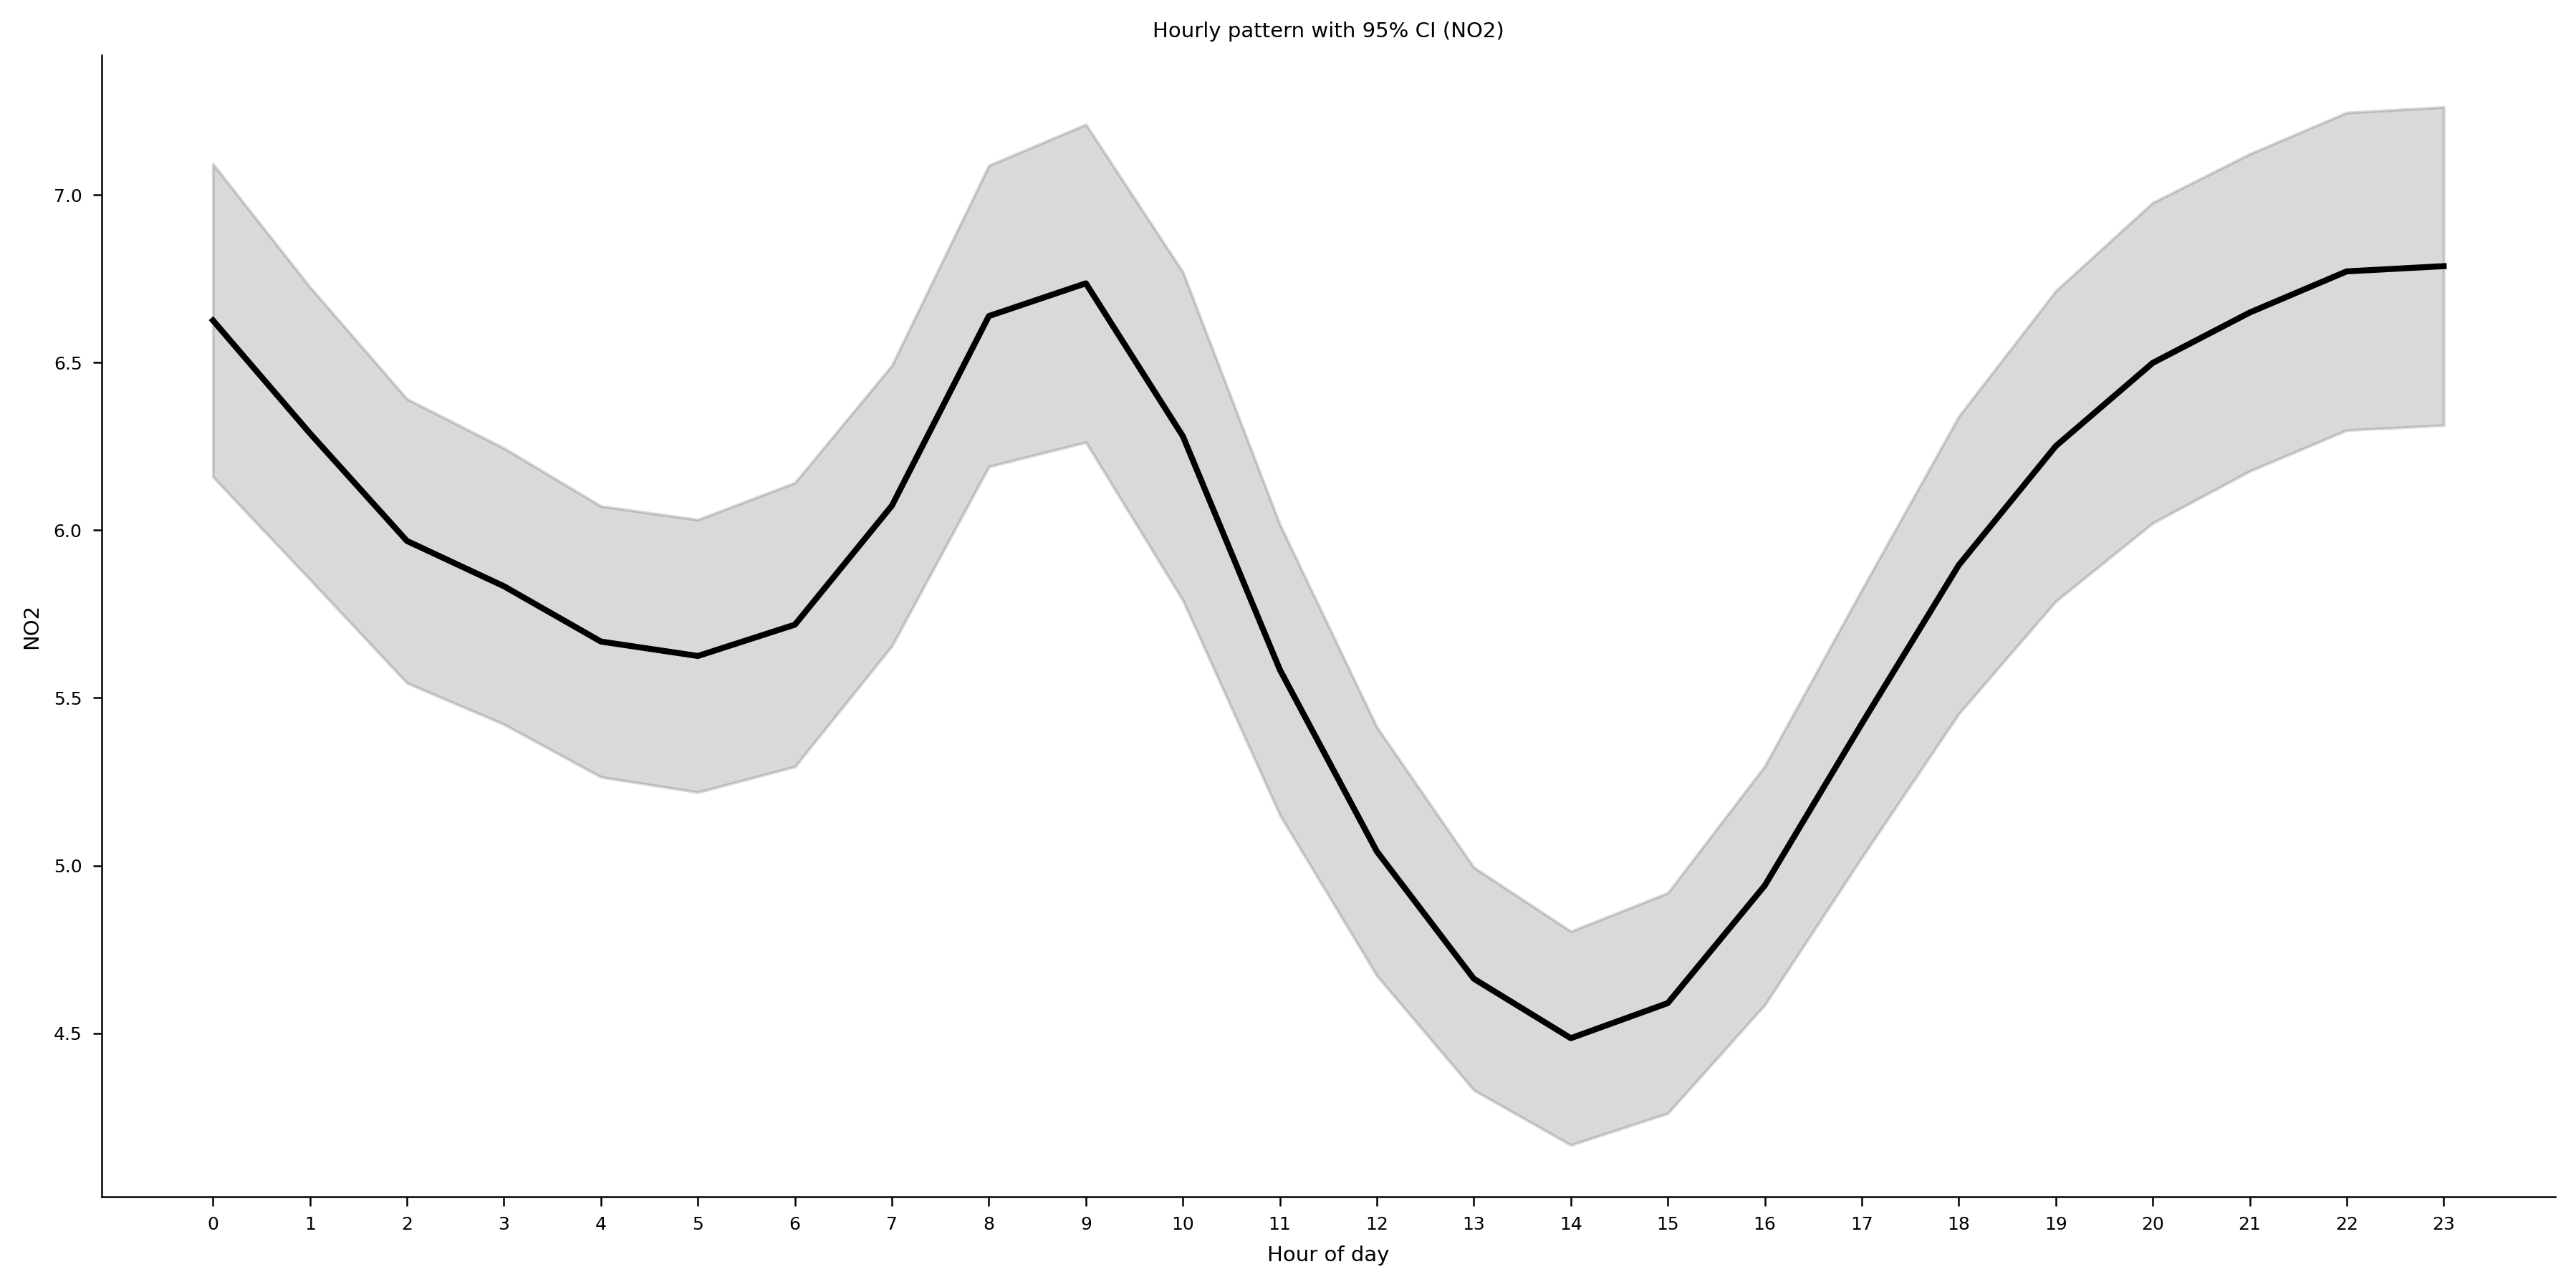

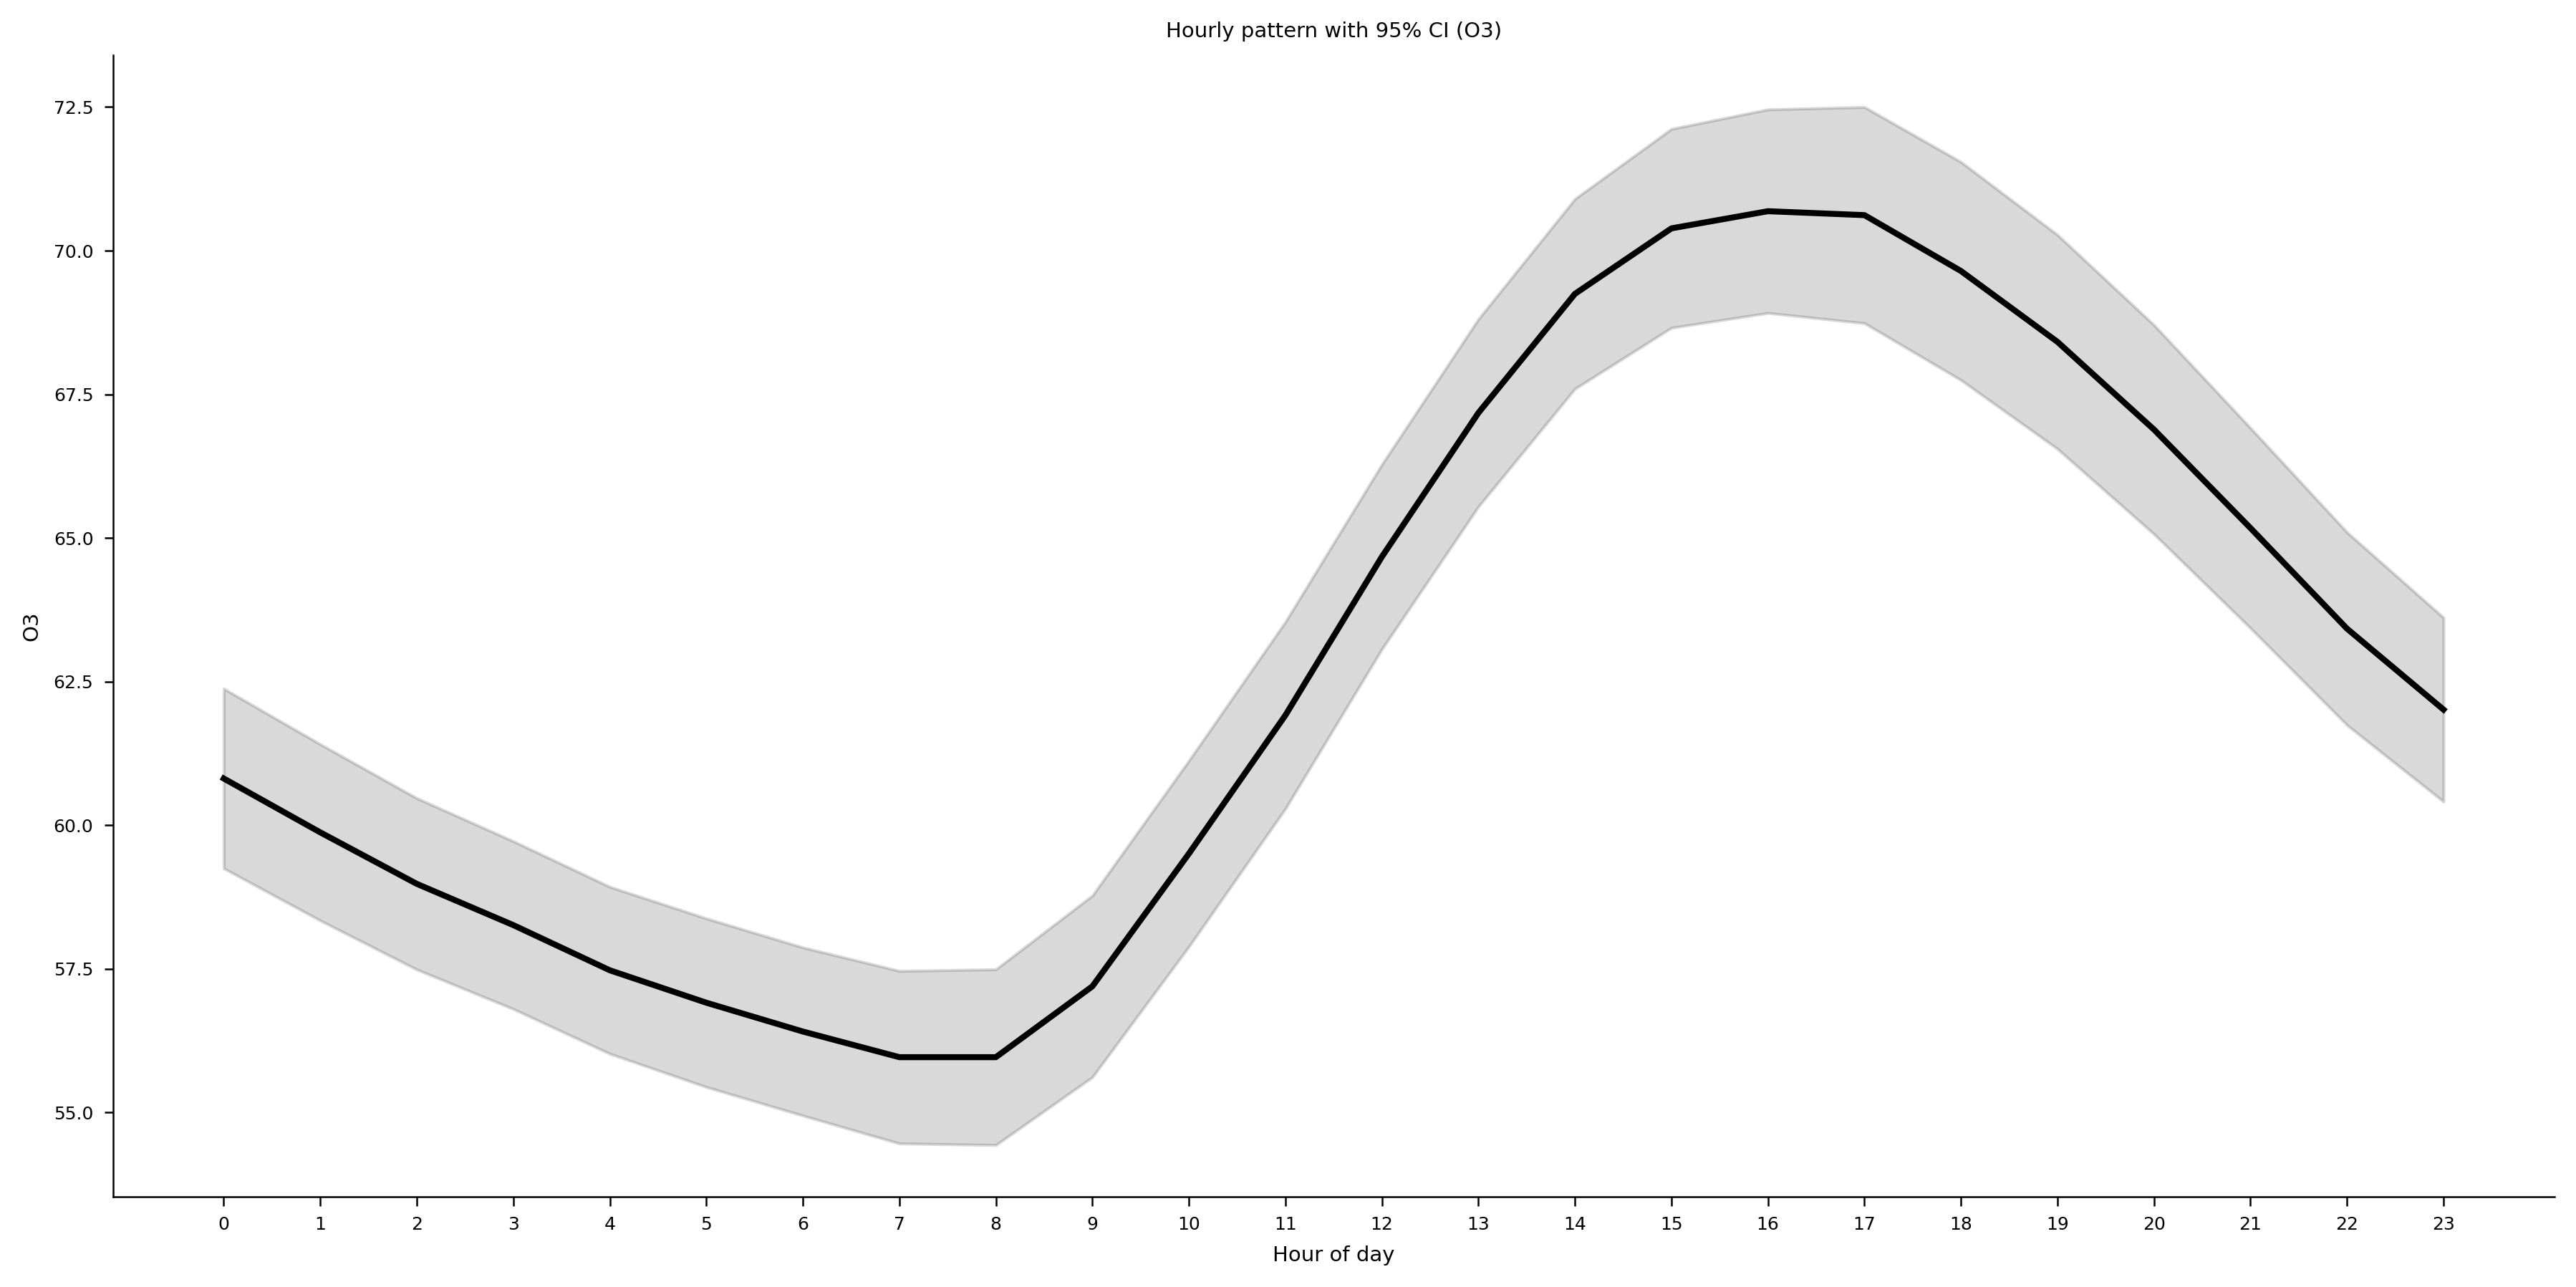

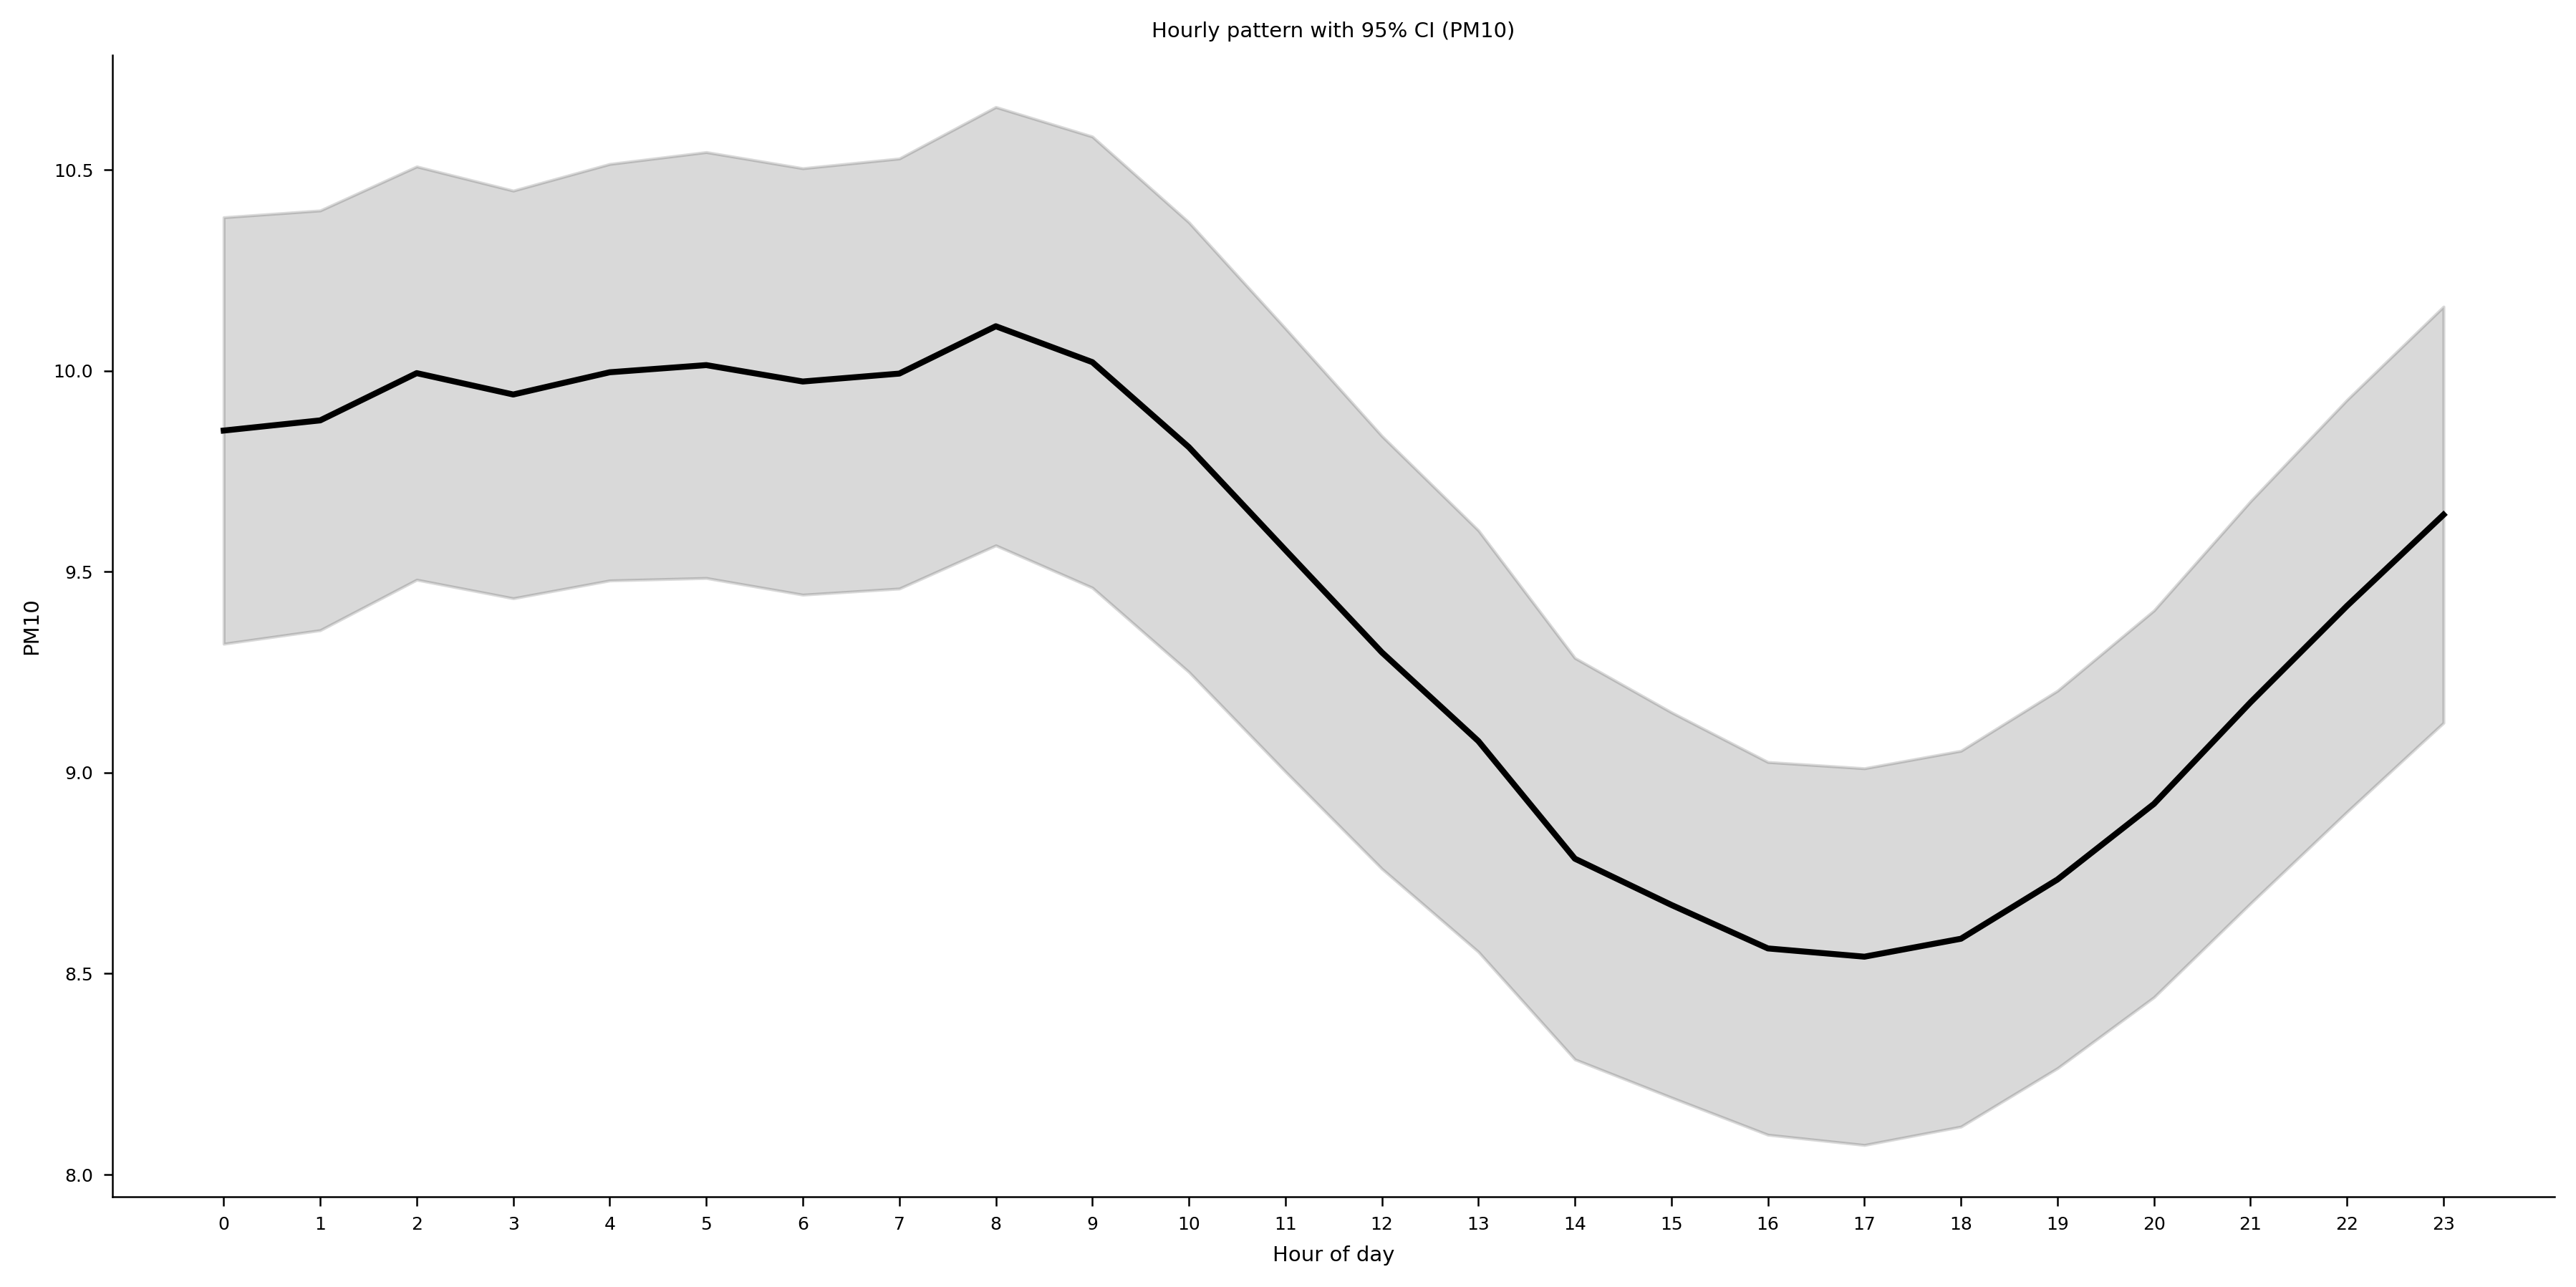

In [18]:

hourly_pattern_ci(df, "PM2.5")
hourly_pattern_ci(df, "NO2")
hourly_pattern_ci(df, "O3")
hourly_pattern_ci(df, "PM10")

# Autocorrelation plots

In [75]:
def plot_acf_variable(df, col, lags=48):
    fig, ax = plt.subplots()

    plot_acf(df[col].dropna(), lags=lags, alpha=.05, ax=ax)

    ax.set_ylim(-0.25, 1.1)

    ax.set_title(f"ACF - {col}")
    plt.tight_layout()
    plt.show()


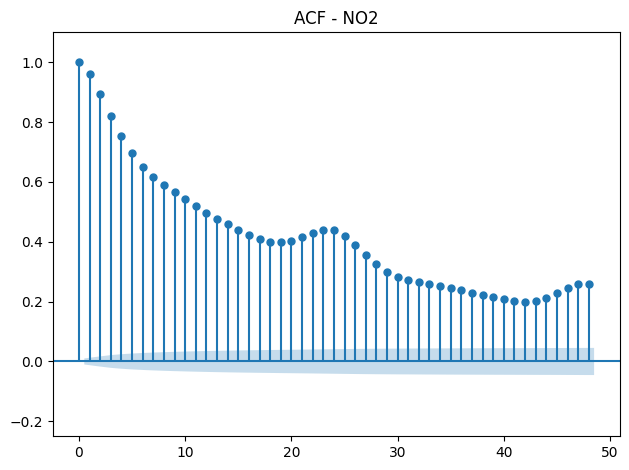

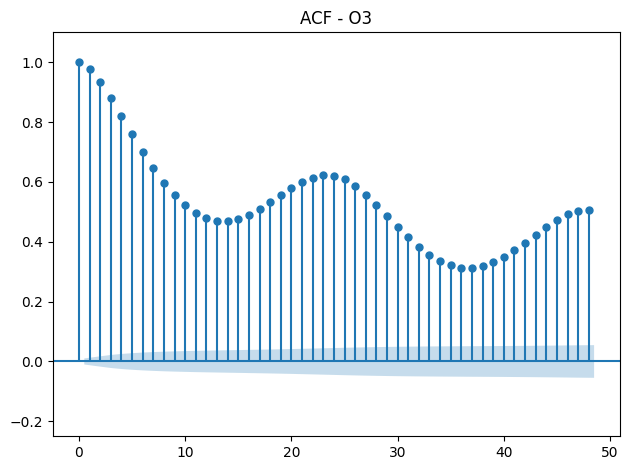

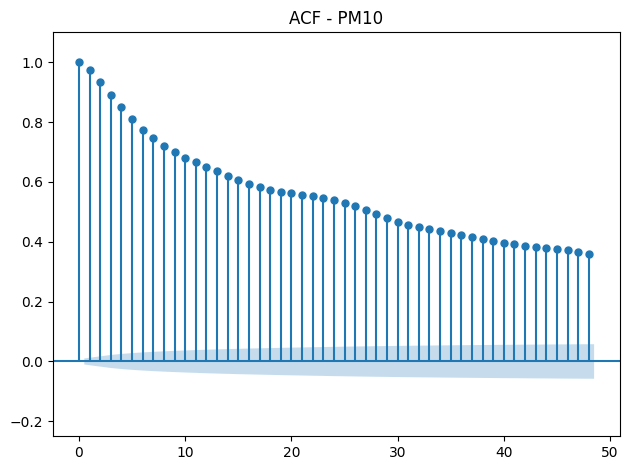

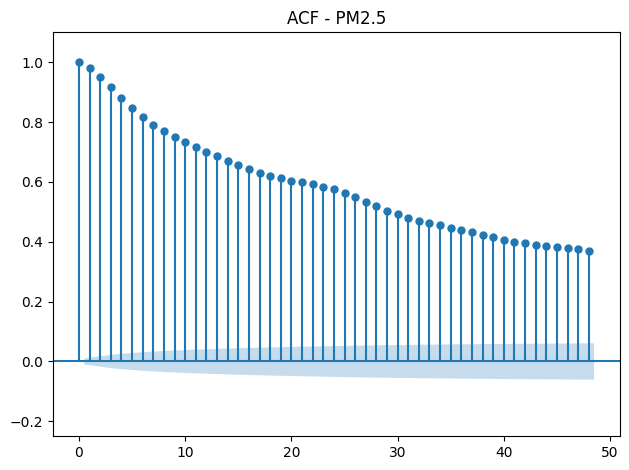

In [76]:

for v in ["NO2", "O3", "PM10", "PM2.5"]:
    plot_acf_variable(df, v)